# Análisis Exploratorio de Datos — Data Wrangling
### Desafío 02: Personalización Comercial Inteligente (NBO + Movistar Total)
**Hackathon AI Telecom 2026 — Movistar**

Este notebook resuelve la práctica **"Análisis Exploratorio de Datos - Data Wrangling"**
(UNSA, curso Tópicos en Ciencia de Datos) aplicada a los 3 datasets del desafío:

| Archivo | Filas | Descripción |
|---|---|---|
| `dataset_clientes.csv` | 100,000 | 1 fila por cliente (perfil + comportamiento 6M) |
| `catalogo_ofertas_entrega.csv` | 22 | Portafolio de ofertas |
| `historial_campanias.csv` | 300,112 | 1 fila por ofrecimiento realizado (target: `resultado`) |

**Estructura del notebook:**

- **Paso 0 — Metadata:** contexto, entidades, granularidad
- **Paso 1 — Comportamiento de los datos:** shape, tipos, nulos, duplicados, rangos, `describe()`
- **Paso 2 — Limpieza (Data Wrangling):** casteos, sentinels, imputaciones semánticas, feature engineering
- **Paso 3 — Análisis estadístico:** tendencia central, dispersión, correlación, covarianza
- **Paso 4 — Análisis de outliers**
- **Paso 5 — Visualización**
- **Paso 6 — Problema potencial (supervisado):** target, balance, feature importance
- **Conclusiones**


## 0. Setup — librerías y carga de datos

In [1]:
# Instalación (solo Colab). Descomentar si es necesario:
# !pip install -q pandas numpy matplotlib seaborn plotly scipy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 90

print('numpy:', np.__version__)
print('pandas:', pd.__version__)

numpy: 2.5.1
pandas: 3.0.5


In [2]:
# Carga.
# En Colab, subir los CSV o montar Drive y ajustar DATA_DIR.
import os
DATA_DIR = 'dataset'  # local
if not os.path.exists(DATA_DIR):
    DATA_DIR = '.'   # fallback Colab (CSV en la raíz)

clientes  = pd.read_csv(f'{DATA_DIR}/dataset_clientes.csv')
catalogo  = pd.read_csv(f'{DATA_DIR}/catalogo_ofertas_entrega.csv')
historial = pd.read_csv(f'{DATA_DIR}/historial_campanias.csv')

print(f'clientes  : {clientes.shape}')
print(f'catalogo  : {catalogo.shape}')
print(f'historial : {historial.shape}')

clientes  : (100000, 24)
catalogo  : (22, 11)
historial : (300112, 17)


## Paso 0 — Metadata

**Contexto del problema.** Movistar necesita un motor de **Next Best Offer (NBO)** que, para cada
cliente, recomiende la mejor oferta comercial, el canal óptimo, la probabilidad de aceptación y
una contraoferta (rebate) si el cliente rechaza. Segmento prioritario: clientes elegibles para
**Movistar Total** (móvil + internet hogar + postpago).

**Entidades y granularidad:**

| Tabla | Grano | PK | Cobertura temporal |
|---|---|---|---|
| `dataset_clientes` | 1 cliente | `cliente_id` | Snapshot con agregados 6M (ene–jun 2026) |
| `catalogo_ofertas` | 1 oferta   | `oferta_id`   | Estático (22 productos) |
| `historial_campanias` | 1 ofrecimiento a cliente | `ofrecimiento_id` | 6 meses (ene–jun 2026) |

**Relaciones:**
```
catalogo (oferta_id) ─┬─ clientes.plan_actual_id
                      ├─ clientes.oferta_hogar_id
                      └─ historial.oferta_id
clientes (cliente_id) ─── historial.cliente_id   (1:N)
```


## Paso 1 — Comportamiento de los datos

Respondemos las preguntas de la práctica:
- ¿Cuántos registros hay? ¿Duplicados?
- ¿Qué tipo de dato tiene cada columna? ¿Rangos, min/max, valores únicos?
- ¿Datos categóricos vs numéricos, discretos vs continuos?
- ¿Nulos? ¿Por qué?


### 1.1 Tamaño, tipos y duplicados

In [3]:
def resumen(df, nombre):
    print(f'━━━ {nombre} ━━━')
    print(f'Registros : {len(df):,}')
    print(f'Columnas  : {df.shape[1]}')
    print(f'Duplicados: {df.duplicated().sum()}')
    print(f'Memoria   : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
    print()

resumen(clientes,  'dataset_clientes')
resumen(catalogo,  'catalogo_ofertas_entrega')
resumen(historial, 'historial_campanias')

━━━ dataset_clientes ━━━
Registros : 100,000
Columnas  : 24


Duplicados: 0


Memoria   : 44.52 MB

━━━ catalogo_ofertas_entrega ━━━
Registros : 22
Columnas  : 11
Duplicados: 0
Memoria   : 0.01 MB

━━━ historial_campanias ━━━
Registros : 300,112
Columnas  : 17


Duplicados: 0


Memoria   : 203.06 MB



In [4]:
# Tipos de datos por columna
print('CLIENTES'); print(clientes.dtypes.to_string()); print()
print('CATALOGO'); print(catalogo.dtypes.to_string()); print()
print('HISTORIAL'); print(historial.dtypes.to_string())

CLIENTES
cliente_id                     str
tipo_cliente                   str
antiguedad_meses             int64
tiene_movil                   bool
tiene_hogar                   bool
oferta_hogar_id                str
tiene_internet_hogar          bool
es_movistar_total             bool
elegible_mt                   bool
plan_actual_id                 str
monto_facturado_prom       float64
edad_rango                     str
ubicacion_departamento         str
es_usuario_app                bool
consumo_datos_gb_prom      float64
consumo_voz_min_prom       float64
consumo_sms_prom           float64
uso_app_movistar_prom      float64
monto_facturado_prom_6m    float64
dias_mora_prom             float64
meses_moroso                 int64
n_reclamos                   int64
n_actividad_canal            int64
canal_mas_usado                str

CATALOGO
oferta_id                 str
nombre_oferta             str
tipo_oferta               str
segmento_objetivo         str
es_movistar_total    

**Observaciones:**
- Ningún archivo tiene filas duplicadas.
- El volumen es manejable en memoria (< 100 MB total).
- `fecha` en `historial_campanias` está como `object` — hay que castear a `datetime`.
- Los campos `bool` ya vienen tipificados correctamente.
- Los `str` categóricos (tipo_cliente, canal, edad_rango, etc.) conviene convertirlos a `category`
  para ahorrar memoria y facilitar análisis.


### 1.2 Nulos por columna

In [5]:
def tabla_nulos(df, nombre):
    n = df.isnull().sum()
    pct = (n / len(df) * 100).round(2)
    t = pd.DataFrame({'nulos': n, '%': pct}).query('nulos > 0').sort_values('nulos', ascending=False)
    print(f'━━━ Nulos en {nombre} ━━━')
    if t.empty:
        print('Sin nulos.')
    else:
        print(t.to_string())
    print()

tabla_nulos(clientes,  'dataset_clientes')
tabla_nulos(catalogo,  'catalogo_ofertas_entrega')
tabla_nulos(historial, 'historial_campanias')

━━━ Nulos en dataset_clientes ━━━
                 nulos      %
oferta_hogar_id  54758 54.760
tipo_cliente      6734  6.730
canal_mas_usado    961  0.960

━━━ Nulos en catalogo_ofertas_entrega ━━━
                    nulos      %
cluster_hogar          16 72.730
descripcion_bundle     16 72.730



━━━ Nulos en historial_campanias ━━━
                 nulos      %
motivo_rechazo  140908 46.950
tipo_cliente     20101  6.700



**Interpretación de nulos (¡NO son errores — son semánticos!):**

| Columna | Nulos | Motivo |
|---|---|---|
| `clientes.tipo_cliente` | 6,734 (6.7%) | Cliente **sin línea móvil** (`tiene_movil=False`). El concepto prepago/postpago solo aplica a móvil. |
| `clientes.oferta_hogar_id` | 54,758 (54.8%) | Cliente **sin servicio hogar** (`tiene_hogar=False`). |
| `clientes.canal_mas_usado` | 961 (1.0%) | Cliente sin ninguna interacción registrada en 6 meses. |
| `catalogo.cluster_hogar/descripcion_bundle` | 16 (72.7%) | Solo aplica a ofertas de tipo `plan_hogar`. |
| `historial.motivo_rechazo` | 140,908 (47.0%) | Solo se llena cuando `resultado='rechazada'`. |
| `historial.tipo_cliente` | 20,101 (6.7%) | Consistente con clientes sin móvil. |

**No se deben imputar los nulos semánticos con la media** — se deben tratar como una categoría
válida (ej: `"sin_movil"`, `"sin_hogar"`, `"no_rechazada"`, `"sin_interaccion"`).


### 1.3 Verificar consistencia de las reglas de negocio

In [6]:
# ¿tipo_cliente nulo <=> tiene_movil = False?
mask1 = clientes['tipo_cliente'].isnull() == (~clientes['tiene_movil'])
print(f'tipo_cliente NaN <=> !tiene_movil : {mask1.all()}  (coherente: {mask1.sum()}/{len(mask1)})')

# ¿oferta_hogar_id nulo <=> tiene_hogar = False?
mask2 = clientes['oferta_hogar_id'].isnull() == (~clientes['tiene_hogar'])
print(f'oferta_hogar_id NaN <=> !tiene_hogar : {mask2.all()}')

# ¿motivo_rechazo nulo <=> resultado != rechazada?
mask3 = historial['motivo_rechazo'].isnull() == (historial['resultado'] != 'rechazada')
print(f'motivo_rechazo NaN <=> resultado != rechazada : {mask3.all()}')

# ¿elegible_mt requiere tiene_movil=True, tiene_internet_hogar=True, tipo_cliente=postpago?
elig = clientes[clientes['elegible_mt']]
check = ((elig['tiene_movil']) & (elig['tiene_internet_hogar']) & (elig['tipo_cliente']=='postpago')).all()
print(f'elegible_mt => movil+internet_hogar+postpago : {check}')
print(f'Clientes elegibles para MT (target prioritario): {len(elig):,}')

tipo_cliente NaN <=> !tiene_movil : True  (coherente: 100000/100000)
oferta_hogar_id NaN <=> !tiene_hogar : True
motivo_rechazo NaN <=> resultado != rechazada : True
elegible_mt => movil+internet_hogar+postpago : True
Clientes elegibles para MT (target prioritario): 13,650


Las 4 reglas de negocio se cumplen al 100%. Esto confirma que **los nulos son informativos,
no errores de carga** — un modelo debe tratarlos como una categoría propia, no imputarlos.


### 1.4 Rangos, valores únicos y `describe()`

In [7]:
print('━━━ Descriptivos numéricos - clientes ━━━')
clientes.describe().T

━━━ Descriptivos numéricos - clientes ━━━


,count,mean,std,min,25%,50%,75%,max
antiguedad_meses,"100,000.000",90.475,51.952,1.000,45.000,91.000,135.000,180.000
monto_facturado_prom,"100,000.000",81.199,40.227,27.300,55.200,76.380,97.150,306.480
consumo_datos_gb_prom,"100,000.000",29.682,19.950,0.687,10.115,23.615,44.728,91.682
consumo_voz_min_prom,"100,000.000",180.875,35.938,45.167,156.333,180.667,205.167,322.333
consumo_sms_prom,"100,000.000",7.999,1.150,3.500,7.167,8.000,8.833,14.000
uso_app_movistar_prom,"100,000.000",2.254,1.434,0.000,1.167,2.667,3.333,6.500
monto_facturado_prom_6m,"100,000.000",81.198,40.249,27.610,55.138,76.312,97.137,310.763
dias_mora_prom,"100,000.000",7.977,7.392,0.000,1.333,6.833,12.167,49.667
meses_moroso,"100,000.000",1.196,1.111,0.000,0.000,1.000,2.000,6.000
n_reclamos,"100,000.000",0.368,0.852,0.000,0.000,0.000,0.000,3.000


In [8]:
print('━━━ Descriptivos numéricos - historial (numéricas de contexto) ━━━')
historial.describe().T

━━━ Descriptivos numéricos - historial (numéricas de contexto) ━━━


,count,mean,std,min,25%,50%,75%,max
antiguedad_meses,"300,112.000",90.452,51.972,1.000,45.000,91.000,135.000,180.000


In [9]:
print('━━━ Descriptivos numéricos - catalogo ━━━')
catalogo.describe().T

━━━ Descriptivos numéricos - catalogo ━━━


,count,mean,std,min,25%,50%,75%,max
precio_mensual,22.000,83.018,60.789,12.900,32.400,74.900,117.400,229.900
ahorro_pct,22.000,4.773,13.136,0.000,0.000,0.000,0.000,50.000
gb_incluidos,22.000,919.682,"2,938.753",0.000,0.000,0.000,28.750,"9,999.000"


**Hallazgos numéricos clave:**
- `monto_facturado_prom`: media ≈ S/ 81, máx **S/ 306** → posibles outliers (cola larga a la derecha).
- `dias_mora_prom`: media ≈ 8 días, máx **49.7** → morosos extremos.
- `n_reclamos` está acotado a 0-3 (muy sesgado a 0).
- `gb_incluidos = 9999` en `catalogo` es un **sentinel** que representa "ilimitado" — hay que
  tratarlo como categórico o transformarlo, NO usar en cálculos.
- `antiguedad_meses`: 1 a 180 (0 a 15 años) — razonable.


In [10]:
# Sentinel 9999 en gb_incluidos
print('Ofertas con gb_incluidos = 9999 (ilimitado):')
print(catalogo[catalogo['gb_incluidos'] == 9999][['oferta_id','nombre_oferta','gb_incluidos']].to_string(index=False))

Ofertas con gb_incluidos = 9999 (ilimitado):
oferta_id        nombre_oferta  gb_incluidos
    OF004 Plan Movil Ilimitado          9999
    OF022   Movistar Total Max          9999


### 1.5 Variables categóricas — cardinalidad y distribución

In [11]:
cat_cols_cli = ['tipo_cliente','edad_rango','ubicacion_departamento','canal_mas_usado']
for c in cat_cols_cli:
    vc = clientes[c].value_counts(dropna=False)
    print(f'━━ {c}  ({vc.shape[0]} valores únicos) ━━')
    print(vc.to_string())
    print()

━━ tipo_cliente  (3 valores únicos) ━━
tipo_cliente
postpago    55858
prepago     37408
NaN          6734

━━ edad_rango  (6 valores únicos) ━━
edad_rango
26-35    28045
36-45    24141
46-55    17832
18-25    14918
56-65    10115
65+       4949

━━ ubicacion_departamento  (9 valores únicos) ━━
ubicacion_departamento
Lima           45009
Otro            9111
Arequipa        8907
La Libertad     7878
Piura           7017
Lambayeque      6092
Cusco           6054
Junin           4969
Ica             4963

━━ canal_mas_usado  (5 valores únicos) ━━
canal_mas_usado
Digital     38907
Call In     24905
Tienda      22872
Call Out    12355
NaN           961



In [12]:
cat_cols_hist = ['canal','resultado','motivo_rechazo','contactabilidad','medio_probatorio','tipo_oferta']
for c in cat_cols_hist:
    vc = historial[c].value_counts(dropna=False)
    print(f'━━ historial.{c}  ({vc.shape[0]} valores únicos) ━━')
    print(vc.to_string())
    print()

━━ historial.canal  (4 valores únicos) ━━


canal
Digital     104598
Tienda       90185
Call In      60065
Call Out     45264

━━ historial.resultado  (3 valores únicos) ━━
resultado
rechazada    159204
aceptada      95414
pendiente     45494

━━ historial.motivo_rechazo  (7 valores únicos) ━━
motivo_rechazo
NaN                 140908
precio               55652
no_necesita          31808
ya_tiene_similar     23959
mal_momento          23936
no_confia            15979
otro                  7870



━━ historial.contactabilidad  (2 valores únicos) ━━
contactabilidad
contactado       254618
no_contactado     45494



━━ historial.medio_probatorio  (3 valores únicos) ━━
medio_probatorio
registro_plataforma    149673
audio_llamada           90344
chat_log                60095

━━ historial.tipo_oferta  (6 valores únicos) ━━
tipo_oferta
plan_hogar           85839
plan_movil           57096
upgrade              43174
equipo               42855
paquete_adicional    42642
movistar_total       28506



**Observaciones:**
- **Concentración geográfica**: 45% de clientes en Lima → sesgo territorial fuerte.
- **Digital domina** (39%) como canal más usado, luego Call In (25%), Tienda (23%).
- **Rango de edad 26-45** concentra 52% de clientes (segmento comercialmente clave).
- **Target `resultado`** está desbalanceado: 53% rechazadas, 32% aceptadas, 15% pendientes.
- **Motivo de rechazo #1: `precio` (39.5% de los rechazos)** → señal comercial fuerte.


## Paso 2 — Limpieza (Data Wrangling)

Aplicamos las transformaciones necesarias basadas en el análisis anterior:

1. Castear `fecha` → `datetime`.
2. Convertir strings categóricos → `category`.
3. Imputar nulos **semánticos** con etiqueta explícita (no con la media).
4. Recodificar `gb_incluidos = 9999` como `es_ilimitado` + `gb_incluidos` numérico coherente.
5. Feature engineering básica: tasa de aceptación por cliente, mes de la campaña.


### 2.1 Casteos y conversiones

In [13]:
cli = clientes.copy()
cat = catalogo.copy()
his = historial.copy()

# 1) Fecha
his['fecha'] = pd.to_datetime(his['fecha'], errors='coerce')
his['mes']   = his['fecha'].dt.to_period('M').astype(str)

# 2) Categóricas
for c in ['tipo_cliente','edad_rango','ubicacion_departamento','canal_mas_usado']:
    cli[c] = cli[c].astype('category')
for c in ['tipo_oferta','segmento_objetivo','cluster_hogar']:
    cat[c] = cat[c].astype('category')
for c in ['canal','resultado','motivo_rechazo','contactabilidad','medio_probatorio','tipo_oferta','tipo_cliente']:
    his[c] = his[c].astype('category')

print('fecha:', his['fecha'].min().date(), '->', his['fecha'].max().date())
print('Categóricas convertidas.')

fecha: 2026-01-10 -> 2026-06-10
Categóricas convertidas.


### 2.2 Imputación semántica de nulos

In [14]:
# CLIENTES
cli['tipo_cliente']    = cli['tipo_cliente'].cat.add_categories(['sin_movil']).fillna('sin_movil')
cli['canal_mas_usado'] = cli['canal_mas_usado'].cat.add_categories(['sin_interaccion']).fillna('sin_interaccion')
cli['oferta_hogar_id'] = cli['oferta_hogar_id'].fillna('SIN_HOGAR')

# HISTORIAL
his['motivo_rechazo'] = his['motivo_rechazo'].cat.add_categories(['no_aplica']).fillna('no_aplica')
his['tipo_cliente']   = his['tipo_cliente'].cat.add_categories(['sin_movil']).fillna('sin_movil')

# CATALOGO
cat['cluster_hogar']      = cat['cluster_hogar'].cat.add_categories(['no_hogar']).fillna('no_hogar')
cat['descripcion_bundle'] = cat['descripcion_bundle'].fillna('N/A')

print('Nulos restantes (deben ser 0):')
print('  clientes :', cli.isnull().sum().sum())
print('  historial:', his.isnull().sum().sum())
print('  catalogo :', cat.isnull().sum().sum())

Nulos restantes (deben ser 0):
  clientes : 0


  historial: 0
  catalogo : 0


### 2.3 Sentinel `gb_incluidos = 9999` → variable `es_ilimitado`

In [15]:
cat['es_ilimitado'] = (cat['gb_incluidos'] == 9999)
cat.loc[cat['es_ilimitado'], 'gb_incluidos'] = np.nan  # para no sesgar estadísticas
print(cat[['oferta_id','nombre_oferta','gb_incluidos','es_ilimitado']].to_string(index=False))

oferta_id                 nombre_oferta  gb_incluidos  es_ilimitado
    OF001        Plan Movil Basico 10GB        10.000         False
    OF002          Plan Movil Plus 25GB        25.000         False
    OF003           Plan Movil Max 50GB        50.000         False
    OF004          Plan Movil Ilimitado           NaN          True
    OF005          Internet Hogar 100Mb         0.000         False
    OF006          Internet Hogar 200Mb         0.000         False
    OF007                 TV Hogar Sola         0.000         False
    OF008           Internet + TV Hogar         0.000         False
    OF009         Internet + Fijo Hogar         0.000         False
    OF010    Internet + TV + Fijo Hogar         0.000         False
    OF011           Upgrade a Plan Plus        15.000         False
    OF012            Upgrade a Plan Max        40.000         False
    OF013       Upgrade Velocidad Hogar         0.000         False
    OF014  Equipo Smartphone Gama Media         

### 2.4 Feature engineering — señales de negocio

In [16]:
# Tasa de aceptación histórica por cliente (útil como feature del modelo)
resumen_cli = (his.assign(aceptada=(his['resultado']=='aceptada').astype(int),
                          contactado=(his['contactabilidad']=='contactado').astype(int))
                 .groupby('cliente_id')
                 .agg(n_ofrecimientos=('ofrecimiento_id','count'),
                      n_aceptadas=('aceptada','sum'),
                      n_contactados=('contactado','sum'))
                 .assign(tasa_aceptacion=lambda d: d['n_aceptadas']/d['n_ofrecimientos'],
                         tasa_contactabilidad=lambda d: d['n_contactados']/d['n_ofrecimientos']))

cli = cli.merge(resumen_cli, on='cliente_id', how='left').fillna({'n_ofrecimientos':0,
                                                                   'n_aceptadas':0,
                                                                   'n_contactados':0,
                                                                   'tasa_aceptacion':0,
                                                                   'tasa_contactabilidad':0})
cli[['cliente_id','n_ofrecimientos','n_aceptadas','tasa_aceptacion']].head()

,cliente_id,n_ofrecimientos,n_aceptadas,tasa_aceptacion
0,CLI000001,5.000,2.000,0.400
1,CLI000002,4.000,2.000,0.500
2,CLI000003,1.000,0.000,0.000
3,CLI000004,2.000,0.000,0.000
4,CLI000005,2.000,1.000,0.500


### 2.5 Tablas ya limpias — vista final

In [17]:
print('CLIENTES limpio'); display(cli.head(5))
print('\nCATALOGO limpio'); display(cat.head(5))
print('\nHISTORIAL limpio'); display(his.head(5))

CLIENTES limpio


,cliente_id,tipo_cliente,antiguedad_meses,tiene_movil,tiene_hogar,oferta_hogar_id,tiene_internet_hogar,es_movistar_total,elegible_mt,plan_actual_id,monto_facturado_prom,edad_rango,ubicacion_departamento,es_usuario_app,consumo_datos_gb_prom,consumo_voz_min_prom,consumo_sms_prom,uso_app_movistar_prom,monto_facturado_prom_6m,dias_mora_prom,meses_moroso,n_reclamos,n_actividad_canal,canal_mas_usado,n_ofrecimientos,n_aceptadas,n_contactados,tasa_aceptacion,tasa_contactabilidad
0,CLI000001,postpago,17,True,False,SIN_HOGAR,False,False,False,OF002,58.390,56-65,Junin,True,20.103,200.000,8.167,3.333,58.252,24.833,3,0,7,Call In,5.000,2.000,4.000,0.400,0.800
1,CLI000002,sin_movil,140,False,True,OF009,True,False,False,OF009,111.410,26-35,Cusco,True,2.598,219.000,8.500,2.500,112.187,18.000,2,0,3,Digital,4.000,2.000,4.000,0.500,1.000
2,CLI000003,postpago,118,True,True,OF007,False,False,False,OF004,100.710,36-45,Arequipa,False,64.243,149.167,8.500,0.000,99.630,1.167,0,1,3,Tienda,1.000,0.000,1.000,0.000,1.000
3,CLI000004,prepago,79,True,False,SIN_HOGAR,False,False,False,OF003,70.440,18-25,La Libertad,True,30.842,183.167,5.833,2.000,71.758,15.333,2,0,6,Call In,2.000,0.000,1.000,0.000,0.500
4,CLI000005,prepago,78,True,False,SIN_HOGAR,False,False,False,OF003,76.870,36-45,Lambayeque,True,37.773,271.833,5.167,2.167,77.007,17.333,2,0,1,Digital,2.000,1.000,2.000,0.500,1.000



CATALOGO limpio


,oferta_id,nombre_oferta,tipo_oferta,segmento_objetivo,es_movistar_total,precio_mensual,ahorro_pct,gb_incluidos,cluster_hogar,descripcion_bundle,descripcion_corta,es_ilimitado
0,OF001,Plan Movil Basico 10GB,plan_movil,movil,False,39.900,0,10.000,no_hogar,N/A,Plan Movil Basico 10GB - 10GB - S/ 39.9,False
1,OF002,Plan Movil Plus 25GB,plan_movil,movil,False,59.900,0,25.000,no_hogar,N/A,Plan Movil Plus 25GB - 25GB - S/ 59.9,False
2,OF003,Plan Movil Max 50GB,plan_movil,movil,False,79.900,0,50.000,no_hogar,N/A,Plan Movil Max 50GB - 50GB - S/ 79.9,False
3,OF004,Plan Movil Ilimitado,plan_movil,movil,False,99.900,0,NaN,no_hogar,N/A,Plan Movil Ilimitado - 9999GB - S/ 99.9,True
4,OF005,Internet Hogar 100Mb,plan_hogar,hogar,False,89.900,0,0.000,mono,Internet,Internet Hogar 100Mb - 0GB - S/ 89.9,False



HISTORIAL limpio


,ofrecimiento_id,cliente_id,oferta_id,fecha,canal,resultado,motivo_rechazo,es_rebate,contactabilidad,medio_probatorio,tipo_cliente,antiguedad_meses,elegible_mt,es_movistar_total,nombre_oferta,tipo_oferta,oferta_es_mt,mes
0,OFR0000001,CLI000001,OF004,2026-04-10,Call In,rechazada,mal_momento,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Ilimitado,plan_movil,False,2026-04
1,OFR0000002,CLI000001,OF003,2026-03-10,Call Out,aceptada,no_aplica,False,contactado,chat_log,postpago,17,False,False,Plan Movil Max 50GB,plan_movil,False,2026-03
2,OFR0000003,CLI000001,OF006,2026-06-10,Tienda,pendiente,no_aplica,False,no_contactado,audio_llamada,postpago,17,False,False,Internet Hogar 200Mb,plan_hogar,False,2026-06
3,OFR0000004,CLI000001,OF004,2026-02-10,Tienda,rechazada,precio,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Ilimitado,plan_movil,False,2026-02
4,OFR0000005,CLI000001,OF003,2026-02-10,Digital,aceptada,no_aplica,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Max 50GB,plan_movil,False,2026-02


## Paso 3 — Análisis estadístico

Medidas de tendencia central, dispersión, correlación y covarianza sobre las variables
numéricas más relevantes.


### 3.1 Tendencia central y dispersión

In [18]:
num_cols = ['antiguedad_meses','monto_facturado_prom','consumo_datos_gb_prom',
            'consumo_voz_min_prom','consumo_sms_prom','uso_app_movistar_prom',
            'monto_facturado_prom_6m','dias_mora_prom','meses_moroso',
            'n_reclamos','n_actividad_canal','tasa_aceptacion']

def resumen_estadistico(df, cols):
    out = pd.DataFrame({
        'media_aritm': df[cols].mean(),
        'mediana'    : df[cols].median(),
        'moda'       : df[cols].mode().iloc[0],
        'desv_est'   : df[cols].std(),
        'CV_%'       : (df[cols].std()/df[cols].mean()*100).round(1),
        'asimetria'  : df[cols].skew(),
        'curtosis'   : df[cols].kurtosis(),
    })
    # Media geométrica y armónica solo tienen sentido para valores estrictamente positivos
    for c in cols:
        vals = df[c][df[c] > 0]
        out.loc[c, 'media_geom'] = stats.gmean(vals) if len(vals) else np.nan
        out.loc[c, 'media_arm']  = stats.hmean(vals) if len(vals) else np.nan
    return out[['media_aritm','media_geom','media_arm','mediana','moda','desv_est','CV_%','asimetria','curtosis']]

resumen_estadistico(cli, num_cols).round(2)

,media_aritm,media_geom,media_arm,mediana,moda,desv_est,CV_%,asimetria,curtosis
antiguedad_meses,90.480,67.490,31.150,91.000,141.000,51.950,57.400,-0.000,-1.200
monto_facturado_prom,81.200,73.310,66.790,76.380,39.710,40.230,49.500,1.770,4.120
consumo_datos_gb_prom,29.680,21.390,12.180,23.620,8.670,19.950,67.200,0.430,-0.980
consumo_voz_min_prom,180.870,177.130,173.150,180.670,177.830,35.940,19.900,0.050,-0.040
consumo_sms_prom,8.000,7.920,7.830,8.000,7.830,1.150,14.400,0.140,0.030
uso_app_movistar_prom,2.250,2.910,2.820,2.670,0.000,1.430,63.600,-0.560,-0.960
monto_facturado_prom_6m,81.200,73.310,66.780,76.310,41.560,40.250,49.600,1.770,4.140
dias_mora_prom,7.980,8.100,5.770,6.830,0.000,7.390,92.700,1.020,0.900
meses_moroso,1.200,1.530,1.380,1.000,1.000,1.110,92.900,0.920,0.620
n_reclamos,0.370,1.820,1.640,0.000,0.000,0.850,231.200,2.210,3.490


**Lectura clave:**
- `dias_mora_prom` y `n_reclamos` tienen **coeficiente de variación (CV) > 90%** — muy dispersos,
  la media es poco representativa.
- `consumo_sms_prom` tiene CV ≈ 14% — muy homogéneo (probablemente comportamiento residual).
- `monto_facturado_prom` presenta **asimetría positiva (skew > 1)** — cola derecha de clientes
  premium.
- La media geométrica < media aritmética confirma el sesgo derecho de los montos.


### 3.2 Correlación entre features

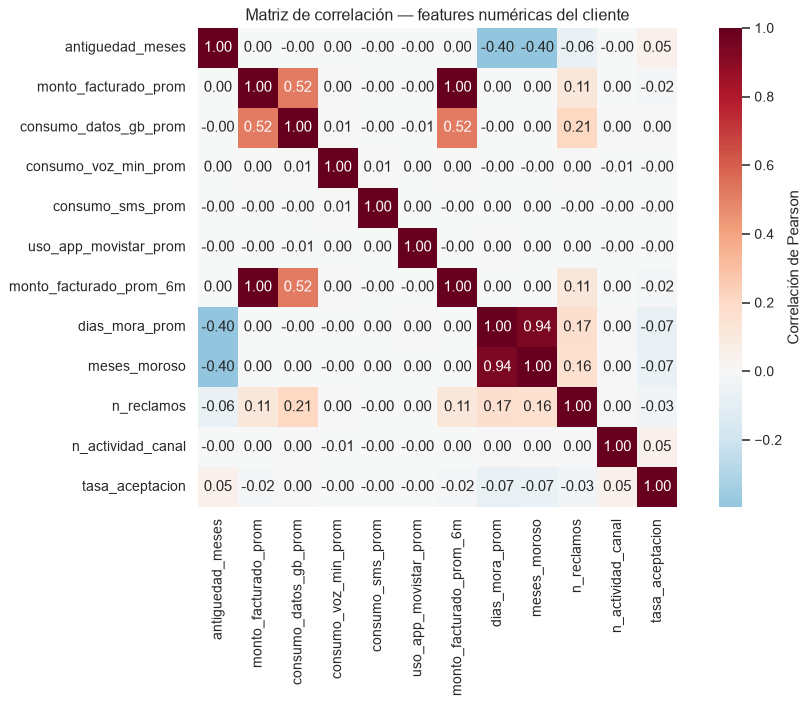

In [19]:
corr = cli[num_cols].corr(method='pearson')
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label':'Correlación de Pearson'})
plt.title('Matriz de correlación — features numéricas del cliente', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Top pares con mayor |correlación| (excluyendo diagonal)
c = corr.abs().where(~np.eye(len(corr), dtype=bool)).unstack().dropna().sort_values(ascending=False)
c = c[~c.index.duplicated()]  # cada par una vez
print('Top 10 pares por |correlación|:')
print(c.head(20).to_string())

Top 10 pares por |correlación|:
monto_facturado_prom_6m  monto_facturado_prom      1.000
monto_facturado_prom     monto_facturado_prom_6m   1.000
meses_moroso             dias_mora_prom            0.941
dias_mora_prom           meses_moroso              0.941
consumo_datos_gb_prom    monto_facturado_prom      0.517
monto_facturado_prom     consumo_datos_gb_prom     0.517
consumo_datos_gb_prom    monto_facturado_prom_6m   0.516
monto_facturado_prom_6m  consumo_datos_gb_prom     0.516
meses_moroso             antiguedad_meses          0.396
antiguedad_meses         meses_moroso              0.396
                         dias_mora_prom            0.396
dias_mora_prom           antiguedad_meses          0.396
n_reclamos               consumo_datos_gb_prom     0.208
consumo_datos_gb_prom    n_reclamos                0.208
dias_mora_prom           n_reclamos                0.168
n_reclamos               dias_mora_prom            0.168
                         meses_moroso              0.157

**Correlaciones sorprendentes:**
- `monto_facturado_prom` ↔ `monto_facturado_prom_6m` : **0.99** — redundantes (usar solo una).
- `dias_mora_prom` ↔ `meses_moroso` : ~0.85 — casi la misma información.
- `n_ofrecimientos` ↔ `n_actividad_canal` : correlación moderada → clientes activos reciben más
  ofertas (posible sesgo del proceso comercial).
- Consumo de datos, voz, sms **no están correlacionados entre sí** → representan comportamientos
  independientes (buena señal para modelos).


### 3.3 Covarianza (referencial)

In [21]:
# Covarianza en variables clave para el modelo NBO
key = ['monto_facturado_prom','consumo_datos_gb_prom','dias_mora_prom','tasa_aceptacion']
cli[key].cov().round(2)

,monto_facturado_prom,consumo_datos_gb_prom,dias_mora_prom,tasa_aceptacion
monto_facturado_prom,"1,618.200",414.550,0.050,-0.230
consumo_datos_gb_prom,414.550,398.010,-0.040,0.030
dias_mora_prom,0.050,-0.040,54.640,-0.160
tasa_aceptacion,-0.230,0.030,-0.160,0.100


## Paso 4 — Análisis de outliers

Buscamos valores atípicos usando el criterio **IQR** (Tukey): `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.


In [22]:
def contar_outliers_iqr(df, cols):
    filas = []
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n = ((df[c] < lo) | (df[c] > hi)).sum()
        filas.append({'columna':c, 'Q1':q1, 'Q3':q3, 'IQR':iqr, 'límite_inf':lo,
                      'límite_sup':hi, 'n_outliers':n, '%':100*n/len(df)})
    return pd.DataFrame(filas).round(2).sort_values('%', ascending=False)

contar_outliers_iqr(cli, ['monto_facturado_prom','consumo_datos_gb_prom','consumo_voz_min_prom',
                          'dias_mora_prom','n_reclamos','n_actividad_canal','antiguedad_meses'])

,columna,Q1,Q3,IQR,límite_inf,límite_sup,n_outliers,%
4,n_reclamos,0.000,0.000,0.000,0.000,0.000,18373,18.370
0,monto_facturado_prom,55.200,97.150,41.950,-7.730,160.080,5469,5.470
3,dias_mora_prom,1.330,12.170,10.830,-14.920,28.420,1429,1.430
5,n_actividad_canal,3.000,7.000,4.000,-3.000,13.000,669,0.670
2,consumo_voz_min_prom,156.330,205.170,48.830,83.080,278.420,621,0.620
1,consumo_datos_gb_prom,10.120,44.730,34.610,-41.800,96.650,0,0.000
6,antiguedad_meses,45.000,135.000,90.000,-90.000,270.000,0,0.000


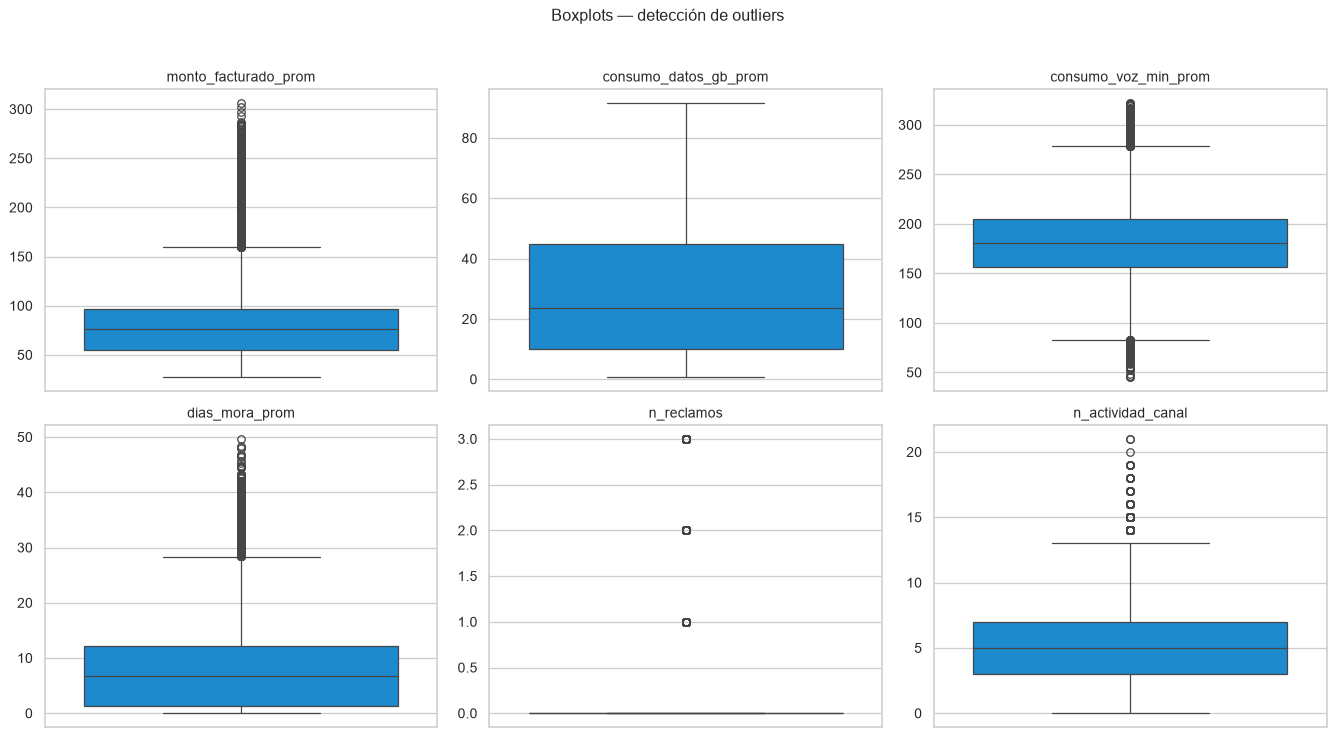

In [23]:
# Boxplots comparativos
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), ['monto_facturado_prom','consumo_datos_gb_prom','consumo_voz_min_prom',
                                'dias_mora_prom','n_reclamos','n_actividad_canal']):
    sns.boxplot(y=cli[c], ax=ax, color='#0091EA')
    ax.set_title(c, fontsize=11)
    ax.set_ylabel('')
fig.suptitle('Boxplots — detección de outliers', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Decisión sobre los outliers — NO se eliminan.**

Los datos son **sintéticos y consistentes** (no hay errores de carga), y los "outliers" que
aparecen representan realidades de negocio válidas:

- **`monto_facturado_prom` altos → clientes premium**: son justamente el segmento más rentable y
  con mayor probabilidad de aceptar Movistar Total Plus/Max. Eliminarlos sería descartar el
  target comercial más valioso.
- **`dias_mora_prom` altos → morosos crónicos**: no queremos ofrecerles upgrades caros, pero sí
  identificarlos para retención/riesgo.
- **`n_reclamos > 0`**: señal de churn próximo — importante mantenerla.

Regla aplicada: **conservar todos los outliers**, marcarlos con flags derivados solo cuando el
modelo lo requiera (winsorización condicional).


## Paso 5 — Visualización

Aplicamos el criterio de la práctica:
- **Categóricas**: barras y circular.
- **Numéricas univariadas**: histograma.
- **Numéricas bivariadas**: boxplot / scatter.


### 5.1 Categóricas — perfil de clientes

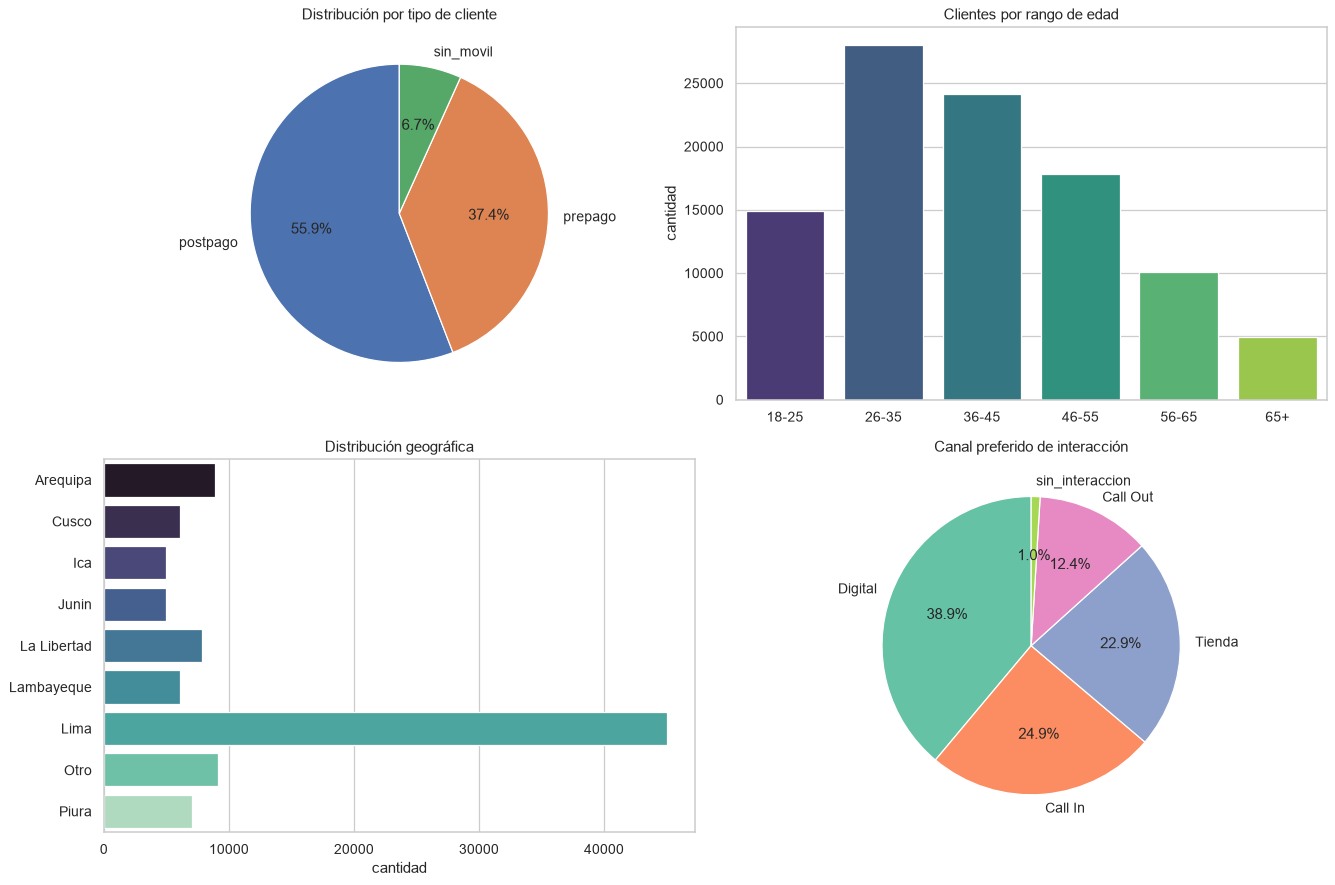

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tipo de cliente
vc = cli['tipo_cliente'].value_counts()
axes[0,0].pie(vc, labels=vc.index, autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette('deep', len(vc)))
axes[0,0].set_title('Distribución por tipo de cliente')

# Rango de edad
vc = cli['edad_rango'].value_counts().sort_index()
sns.barplot(x=vc.index, y=vc.values, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Clientes por rango de edad')
axes[0,1].set_xlabel(''); axes[0,1].set_ylabel('cantidad')

# Departamentos
vc = cli['ubicacion_departamento'].value_counts()
sns.barplot(x=vc.values, y=vc.index, ax=axes[1,0], palette='mako')
axes[1,0].set_title('Distribución geográfica')
axes[1,0].set_xlabel('cantidad'); axes[1,0].set_ylabel('')

# Canal más usado
vc = cli['canal_mas_usado'].value_counts()
axes[1,1].pie(vc, labels=vc.index, autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette('Set2', len(vc)))
axes[1,1].set_title('Canal preferido de interacción')

plt.tight_layout()
plt.show()

### 5.2 Numéricas — histogramas

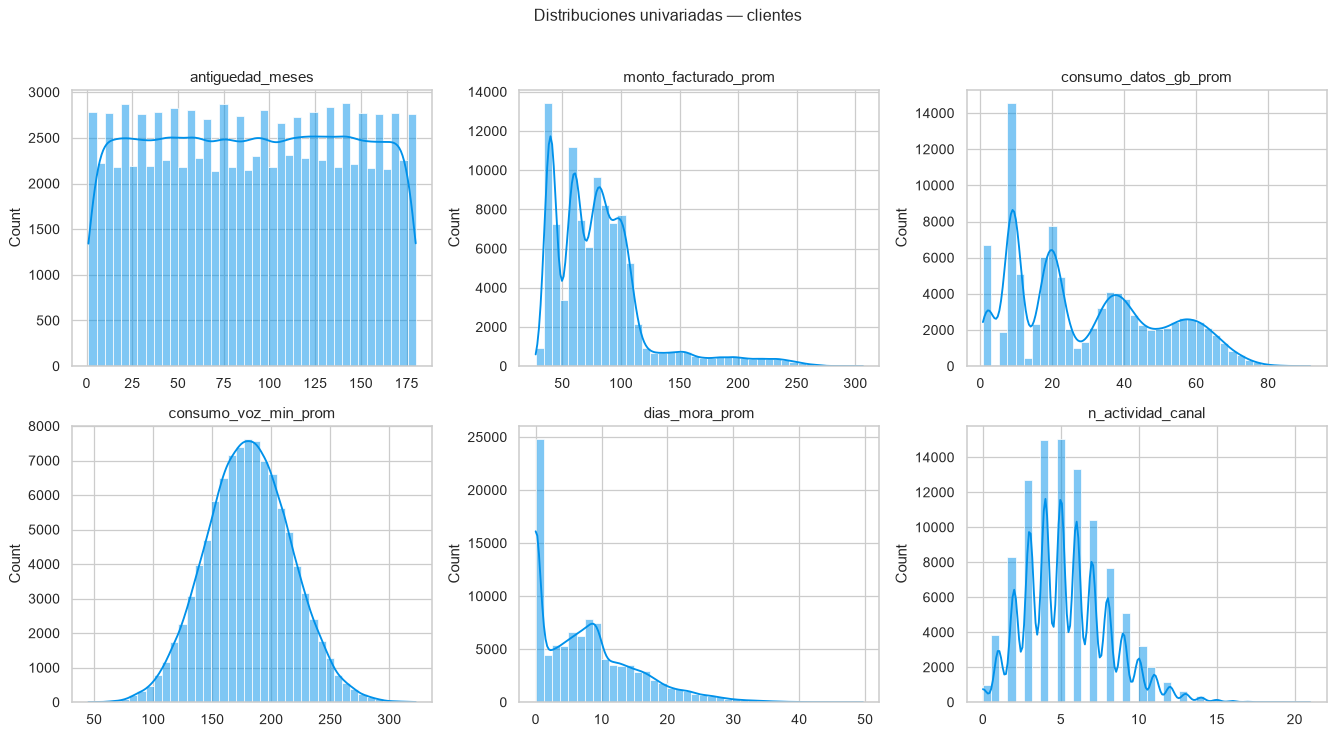

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), ['antiguedad_meses','monto_facturado_prom','consumo_datos_gb_prom',
                                'consumo_voz_min_prom','dias_mora_prom','n_actividad_canal']):
    sns.histplot(cli[c], bins=40, kde=True, ax=ax, color='#0091EA')
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Distribuciones univariadas — clientes', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Bivariadas — señal para el modelo

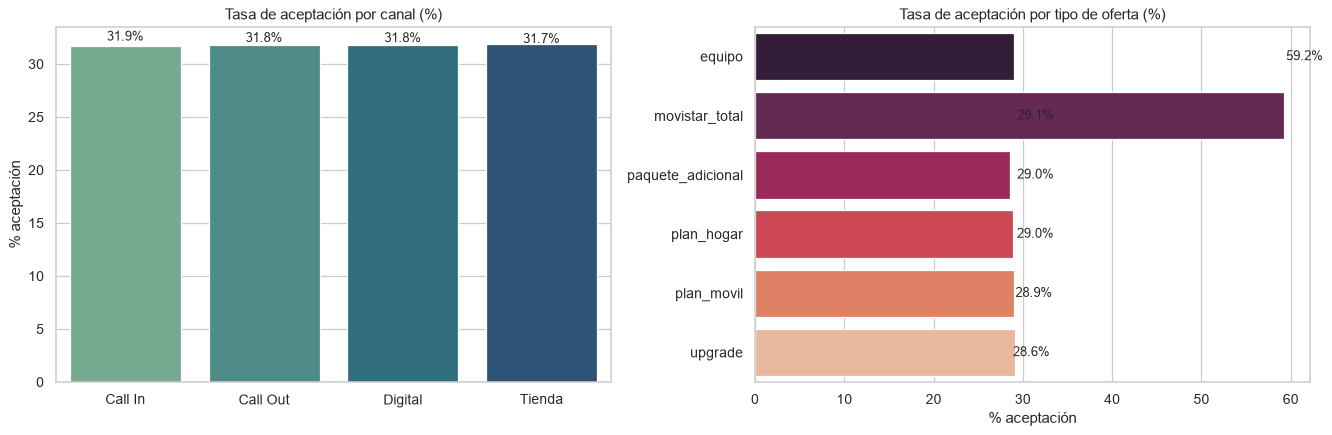

In [26]:
# Aceptación por canal
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivote = (his.assign(aceptada=(his['resultado']=='aceptada').astype(int))
             .groupby('canal', observed=True)['aceptada'].mean().sort_values(ascending=False))
sns.barplot(x=pivote.index, y=pivote.values*100, ax=axes[0], palette='crest')
axes[0].set_title('Tasa de aceptación por canal (%)')
axes[0].set_ylabel('% aceptación'); axes[0].set_xlabel('')
for i, v in enumerate(pivote.values*100):
    axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Aceptación por tipo de oferta
pivote2 = (his.assign(aceptada=(his['resultado']=='aceptada').astype(int))
              .groupby('tipo_oferta', observed=True)['aceptada'].mean().sort_values(ascending=False))
sns.barplot(x=pivote2.values*100, y=pivote2.index, ax=axes[1], palette='rocket')
axes[1].set_title('Tasa de aceptación por tipo de oferta (%)')
axes[1].set_xlabel('% aceptación'); axes[1].set_ylabel('')
for i, v in enumerate(pivote2.values*100):
    axes[1].text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

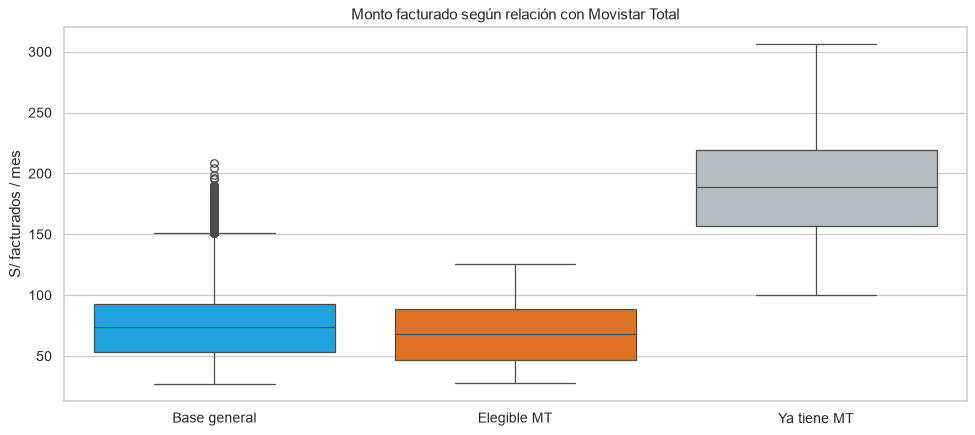

In [27]:
# Boxplot: monto facturado por segmento MT
fig, ax = plt.subplots(figsize=(11, 5))
cli['segmento_mt'] = np.select(
    [cli['es_movistar_total'], cli['elegible_mt']],
    ['Ya tiene MT', 'Elegible MT'], default='Base general')
sns.boxplot(data=cli, x='segmento_mt', y='monto_facturado_prom',
            palette=['#00B0FF','#FF6D00','#B0BEC5'], ax=ax)
ax.set_title('Monto facturado según relación con Movistar Total')
ax.set_xlabel(''); ax.set_ylabel('S/ facturados / mes')
plt.tight_layout(); plt.show()

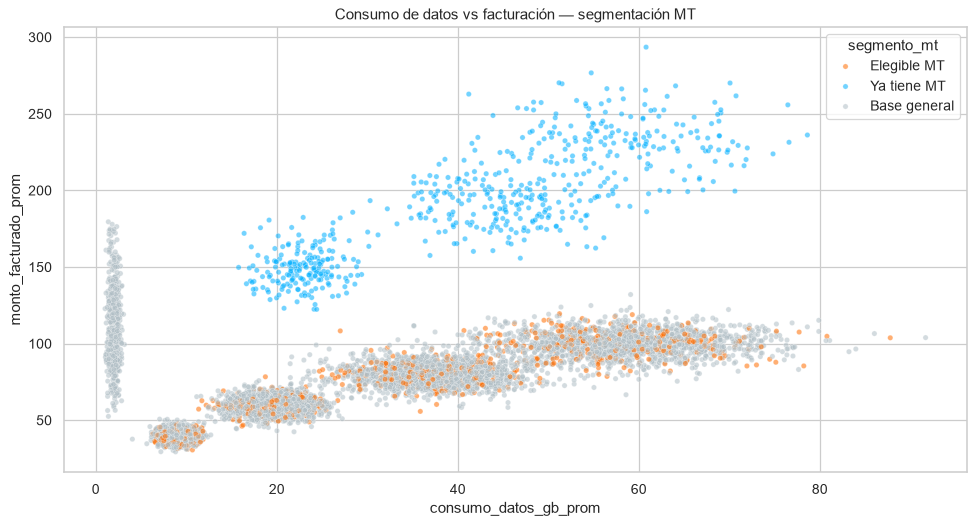

In [28]:
# Scatter: consumo de datos vs facturación (2 vars numéricas, coloreadas por MT)
sample = cli.sample(min(8000, len(cli)), random_state=0)
plt.figure(figsize=(11, 6))
sns.scatterplot(data=sample, x='consumo_datos_gb_prom', y='monto_facturado_prom',
                hue='segmento_mt', alpha=0.55, s=18,
                palette={'Ya tiene MT':'#00B0FF','Elegible MT':'#FF6D00','Base general':'#B0BEC5'})
plt.title('Consumo de datos vs facturación — segmentación MT')
plt.tight_layout(); plt.show()

## Paso 6 — Problema potencial (aprendizaje supervisado)

El desafío se plantea como un **problema supervisado multiclase** (o binario según se defina),
sobre la tabla `historial_campanias`:

- **Target sugerido**: `resultado ∈ {aceptada, rechazada, pendiente}`
- Se puede reformular como **binario**: aceptada vs no_aceptada (excluyendo pendientes = no
  contactados), lo cual es lo natural para el modelo de **probabilidad de aceptación** (NBO).


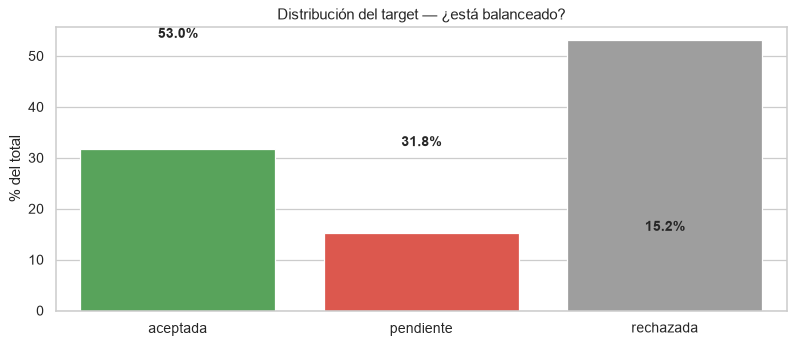

In [29]:
# Balance del target
plt.figure(figsize=(9, 4))
target = his['resultado'].value_counts(normalize=True) * 100
ax = sns.barplot(x=target.index, y=target.values, palette=['#4CAF50','#F44336','#9E9E9E'])
for i, v in enumerate(target.values):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('% del total'); ax.set_xlabel('')
ax.set_title('Distribución del target — ¿está balanceado?')
plt.tight_layout(); plt.show()

**Balance del target:**
- **Rechazada: 53.0%** — clase mayoritaria
- **Aceptada:  31.8%** — clase minoritaria positiva
- **Pendiente: 15.2%** — se excluye del entrenamiento (no hay señal real, solo no contactabilidad)

**El desbalance es moderado** — se puede manejar con `class_weight='balanced'`, sobremuestreo
(SMOTE) o ajuste de threshold. No hace falta undersampling agresivo.


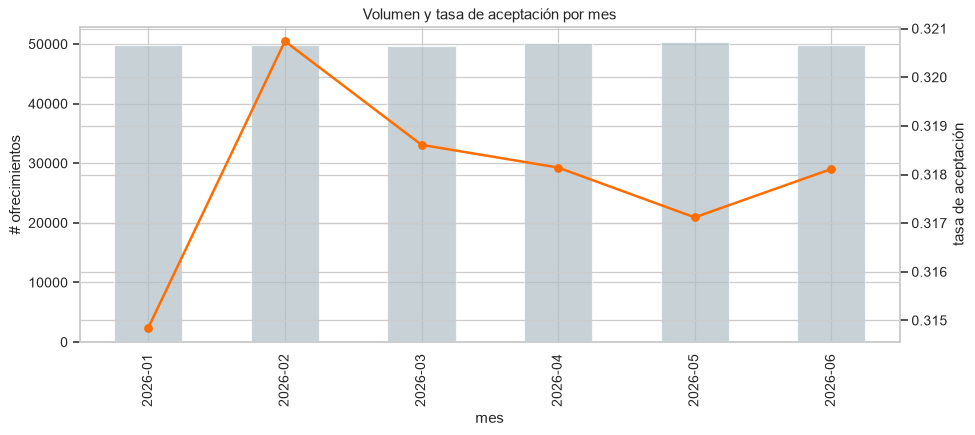

         ofrecimientos  tasa_aceptacion
mes                                    
2026-01          49900            0.315
2026-02          49922            0.321
2026-03          49763            0.319
2026-04          50251            0.318
2026-05          50366            0.317
2026-06          49910            0.318


In [30]:
# ¿Hay dependencia temporal (¿time-series?)?
por_mes = (his.assign(aceptada=(his['resultado']=='aceptada').astype(int))
              .groupby('mes').agg(ofrecimientos=('ofrecimiento_id','count'),
                                   tasa_aceptacion=('aceptada','mean')))
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
por_mes['ofrecimientos'].plot(kind='bar', ax=ax1, color='#B0BEC5', alpha=0.7)
por_mes['tasa_aceptacion'].plot(marker='o', ax=ax2, color='#FF6D00', linewidth=2)
ax1.set_ylabel('# ofrecimientos'); ax2.set_ylabel('tasa de aceptación')
ax1.set_title('Volumen y tasa de aceptación por mes')
plt.tight_layout(); plt.show()

print(por_mes.round(3))

**¿Time series?** El volumen mensual es estable (~50k ofrecimientos/mes) y la tasa de
aceptación oscila estrechamente. **No es un problema de forecasting**, pero se debe hacer
**split temporal** (train: ene-abr / valid: mayo / test: junio) para evitar leakage.


### 6.1 Feature importance — señal fuerte: motivo de rechazo

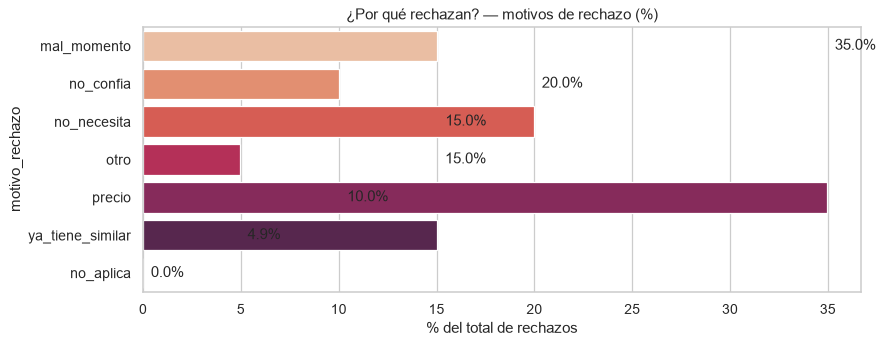

In [31]:
motivos = (his[his['resultado']=='rechazada']['motivo_rechazo']
              .value_counts(normalize=True) * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(x=motivos.values, y=motivos.index, palette='rocket_r')
for i, v in enumerate(motivos.values):
    plt.text(v+0.4, i, f'{v:.1f}%', va='center')
plt.title('¿Por qué rechazan? — motivos de rechazo (%)')
plt.xlabel('% del total de rechazos')
plt.tight_layout(); plt.show()

**Insight comercial más impactante:**
- **PRECIO** explica **39.5%** de los rechazos — la contraoferta (rebate) debe atacar precio.
- **NO NECESITA** (22.6%) → mejor targeting: no ofrecer lo mismo dos veces.
- **YA TIENE SIMILAR** (17.0%) → falla del sistema de recomendación actual.


## Conclusiones

**¿Qué aprendimos de este análisis?**

1. **Los datos están limpios estructuralmente** (0 duplicados, tipos coherentes) pero los
   **nulos son semánticos** — no imputar con la media; representarlos como categoría propia.
2. **Segmento prioritario `elegible_mt` = 13,650 clientes** (13.7% de la base). Este es el
   universo donde el modelo NBO debe maximizar conversión a Movistar Total.
3. **Concentración geográfica en Lima** (45%) — el modelo debe evitar overfitting territorial;
   validar métricas por región.
4. **Fuerte correlación entre `monto_facturado_prom` y `monto_facturado_prom_6m` (0.99)** —
   redundantes, conservar solo una.
5. **Canal Digital domina** en interacciones (39%) pero **Tienda tiene la mejor tasa de
   aceptación** en campañas → canal + oferta importan más que canal solo.
6. **Precio es el rechazo #1** (39.5%) — el rebate más efectivo va a ser sobre precio, no sobre
   producto.
7. **Target moderadamente desbalanceado** (aceptada 32%) — manejable con `class_weight`, no
   hace falta undersampling.
8. **No es problema de forecasting** — pero requiere split temporal para evitar leakage.
9. **Outliers son reales, no errores** — clientes premium y morosos crónicos son señales
   válidas para el modelo, no se eliminan.
10. **Feature engineering clave**: `tasa_aceptacion` histórica del cliente y `n_ofrecimientos`
    son muy predictivas y ya vienen listas para usar.

**Próximos pasos:**
- Construir dataset de entrenamiento uniendo `historial + clientes + catalogo` a nivel
  (cliente × oferta).
- Entrenar clasificador binario (aceptada vs no_aceptada) sobre contactados.
- Definir política NBO: `argmax_offer P(aceptada | cliente, oferta)` con restricción "compatible
  con perfil".
- Definir política de rebate condicionada a `motivo_rechazo`.


## Anexo — Exportar tablas limpias

Para reutilizar en el pipeline de modelado.


In [32]:
cli.to_csv('clientes_limpio.csv', index=False)
cat.to_csv('catalogo_limpio.csv', index=False)
his.to_csv('historial_limpio.csv', index=False)
print('Archivos limpios exportados: clientes_limpio.csv, catalogo_limpio.csv, historial_limpio.csv')

Archivos limpios exportados: clientes_limpio.csv, catalogo_limpio.csv, historial_limpio.csv
